In [10]:
"""Inserts"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Any, Callable


## I. First Model: KNN Method

### 1. Missing Values / Outliers managers

In [11]:
def window_cleaning(rows: pd.DataFrame, margin: float = 1.5) -> pd.DataFrame:

    """Cleans a set of rows by computing the median, and cutting the values under and above a
    certain distance of it (corresponding to margin-times the standart error) and replacing
    these values by the median.
    Args:
        rows: the rows to clean.
        margin: coefficient of the standart error to create an interval of "okay" values.
    Returns:
        rows: same rows with replaced outliers.
    """

    med = np.median(rows.dropna()["temperature"])
    std_error = np.std(rows.dropna()["temperature"])
    lb = med - margin*std_error
    ub = med + margin*std_error

    i = 0
    for _, row in rows.iterrows():
        if (row["temperature"] < lb) or (row["temperature"] > ub):
            rows.iat[i, 2] = med
        rows.fillna(med)
        i += 1
    
    return rows


def preprocessing(sensors_set: pd.DataFrame, window: int = 50, margin: float = 1.5) -> pd.DataFrame:

    """The global function to preprocess the Data. It cleans each sensor one by one by looking
    at 'windows' of time values on their data, computing the median on such intervals, and
    replacing too-far values of the median by itself.
    Args:
        sensors_set: dataset of all sensors to preprocess, with values of time,
         power and temperature.
        window: amount of rows to take to compute the median.
        margin: size of the safe zone, where the values are kept around the median.
    Returns:
        sensors_set: with cleaner data
    """

    new_set = pd.DataFrame({"time":[],"power":[],"temperature":[]})
    new_set.index.name = "sensor"

    for sample in sensors_set.index.unique(): # We pick every specific sensor of the dataset

        for pow in range(3):
            
            rows = sensors_set.loc[sample] # All the temperatures of a given sample
            n = int(rows.shape[0]/3)
            rows = rows.iloc[int(n*pow) : int(n*(pow + 1))] # for a given power


            for t in range(0, n - window, window): # for each time-window

                window_rows = rows.query("@t*864000 <= time < (@t + @window)*864000")
                new_set = pd.concat([new_set, window_cleaning(rows=window_rows, margin=margin)])


            # Last rows cleaning: we may have missed some values with our window-long steps
            t = n - window
            window_rows = rows.query("@t*864000 <= time")
            new_set = pd.concat([new_set,window_cleaning(rows=window_rows, margin=margin)])
    
    return new_set

### 2. Distance Metrics

In [12]:
def man_dist(sample_coo: pd.DataFrame, train_set_coo: pd.DataFrame) -> pd.DataFrame:

    """Computes the Manhattan distance between a sample and all train sensors, and add
    their values in a new column of train_set_coo.
    Args:
        sample_coo: Dataset of the sample's coordinates
        train_set_coo: Dataset of the sensors' coordinates
    Returns:
        train_set_coo_with_dist: train_set_coo with a column "distance", filled.
    """

    coor_train = np.array([train_set_coo["coor_x"], train_set_coo["coor_y"]]).T
    coor_sample = np.array([sample_coo["coor_x"], sample_coo["coor_y"]])

    train_set_coo["distance"] = np.abs(coor_train - coor_sample).sum(axis = 1)

    return train_set_coo
   


def eucli_dist(sample_coo: pd.DataFrame, train_set_coo: pd.DataFrame) -> pd.DataFrame:

    """Computes the Euclidian distance between a sample and all train sensors, and add
    their values in a new column of train_set_coo.
    Args:
        sample_coo: Dataset of the sample's coordinates
        train_set_coo: Dataset of the sensors' coordinates
    Returns:
        train_set_coo_with_dist: train_set_coo with a column "distance", filled.
    """
    
    coor_train = np.array([train_set_coo["coor_x"], train_set_coo["coor_y"]]).T
    coor_sample = np.array([sample_coo["coor_x"], sample_coo["coor_y"]])

    train_set_coo["distance"] = np.sqrt(((coor_train - coor_sample) ** 2).sum(axis = 1))

    return train_set_coo


### 3. Distance Score

In [13]:
def distance_score(neighbors:pd.DataFrame,
                   score_parameter: float = 1) -> pd.DataFrame:
    
    """Replace the "distance" column by a "score" one to each given neighbor sensor,
    depending on their distance to the sample.
    The closer is the sample, the higher the score. We set an upper limit to it
    to avoid giving "blind confidence" to "very close" sensors.
    Args:
        neighbors: neighbor sensors, with "distance" column, regarding the sample.
        score_parameter: Hyper-parameter, set to 1 by default.
    Returns:
        neighbors: Updated with the "score" column.
    """

    scores = 1 / (score_parameter * neighbors["distance"] + 1)

    # We replace the distance column (which we don't need anymore) by the "score" one.
    neighbors["score"] = scores
    neighbors.drop(labels = ["distance"], axis = 1, inplace = True)
    
    return neighbors

### 4. K-Nearest Neighbors

In [14]:
def find_nearest_neighbors(
    sample_coo: pd.DataFrame, 
    train_set_coo: pd.DataFrame, 
    distance_fn: Callable = eucli_dist, 
    k: int = 7,
    score_parameter: int = 1) -> pd.DataFrame:
    
    """Finds the names and distance-scores of the k-Nearest Neighbors of one sample.
    Args:
        sample_coo: Coordinates of the sample.
        train_set_coo: Dataset of the the sensors' coordinates.
        distance_fn: Distance function.
        k: Number of nearest neighbors considered, set to 7 by default.
        score_parameter: Hyper-parameter of distance score, set to 1 by default.
    Returns:
        neighbors: dataframe of the k-nearest neighbors of the sample, with their distance's scores
        stored in a new "score" column.
    """

    train_set_with_dist = distance_fn(sample_coo, train_set_coo) # We compute the distances of sample to all sensors 
    neighbors = distance_score(neighbors= train_set_with_dist.sort_values(by=["distance"]).head(k),
                               score_parameter= score_parameter) # We select the closest ones, and replace distance by score
    
    return neighbors

### 5. Prediction Functions

In [15]:
def prediction_single(
    sample_values: pd.DataFrame,
    neighbors_values: pd.DataFrame,
    neighbors_scores: pd.DataFrame) -> float:

    """Gives the final prediction of a given sample's temperature, while calling KNN. Calculates the
    mean value of the temperatures of the neighbors, weighted by their distance scores.
    Args:
        sample_values: The dataframe with all times and powers at which evaluate given sensor.
        neighbors_values: The dataframe of values of the k-neighbors of the sample.
        neighbors_scores: The dataframe of scores (and coordinates) of the neighbors.
    Returns:
        pred: The values of the predicted temperatures of the sample, for all times and powers.
    """

    pred = []

    for _, row in sample_values.iterrows():
        temperatures = neighbors_values.query('time == @row.time and power == @row.power')["temperature"]
        pred.append(np.sum(temperatures * neighbors_scores["score"]) / np.sum(neighbors_scores["score"]))

    return np.array(pred)



def prediction(
    validation_set_coo: pd.DataFrame,
    validation_set_values:pd.DataFrame,
    train_set_coo: pd.DataFrame,
    train_set_values: pd.DataFrame,
    distance_fn: Callable = eucli_dist, 
    k: int = 7,
    score_parameter: int = 1) -> pd.DataFrame:

    """Gives the final predictions of all validation-set temperatures, while calling prediction_single.
    Args:
        validation_set_coo: Dataframe with names and coordinates of some sensors whom we "hide" the
         temperature values.
        validation_set_values: Dataframe with names, times and powers of the validation set at which we want the
         model to evaluate the temperature (times with "not nan" temperatures)
        train_set_coo: Dataset of the "train" sensors' coordinates.
        train_set_values: Dataset of the "train" sensors' values of time, power and temperature.
        distance_fn: Distance function (among Manhattan or Euclidian)
        k: Number of nearest neighbors taken, set to 7 by default
        score_parameter: Hyper-parameter of distance score, set to 1 by default.

    Returns:
        pred: validation_set_values with a column "prediction", filled with the outputs of prediction_single.
    """

    # Empty array in which we'll store our predictions
    prediction_values = np.array([])

    for sensor_name, row in validation_set_coo.iterrows():

        neighbors = find_nearest_neighbors(sample_coo = row,
                                           train_set_coo = train_set_coo,
                                           distance_fn = distance_fn,
                                           k = k, 
                                           score_parameter=score_parameter)
        
        prediction_values = np.append(prediction_values, prediction_single(sample_values= validation_set_values.loc[sensor_name],
                                                                           neighbors_values= train_set_values.loc[neighbors.index],
                                                                           neighbors_scores= neighbors))

    # Adding the column "prediction" to our validation set
    validation_set_values["prediction"] =  prediction_values

    return validation_set_values

### 6. Loss Function

In [16]:
def loss(ground_truths: pd.DataFrame, prediction_set: pd.DataFrame) -> float:
    
    """ Computes the mean error of the model.
    Args:
        ground_truths: Dataframe of the name of the sensors with their time, and real temperatures.
        prediction_set: Our "Prediction" dataframe, of the same structure as ground_truths, but with
        a column "prediction" instead of "temperature".
    Returns:
        float: The loss
    """
    
    real_temp = ground_truths["temperature"]
    predictions = prediction_set["prediction"]

    return np.mean(np.abs(real_temp - predictions))

### Training Session

In [20]:
# Reading data
training_data=pd.read_parquet("data_parquet_2026/train.parquet").set_index(keys= "sensor")
training_data.drop(labels=["N277","N927"], inplace = True) # We drop the 2 "dummy" sensors' values

sensors = pd.read_parquet("data_parquet_2026/sensors.parquet").drop(columns=["coor_z"]).drop_duplicates().set_index(keys= "sensor")
sensors.drop(labels=["N2","N277","N927"], inplace = True) # We drop also a third sensor with no values

test_data = pd.read_parquet("data_parquet_2026/test.parquet").set_index(keys= "sensor")


In [21]:
"""Dropping the test sensors, as we will train the model only with the training data"""
test_sensors = test_data.index.unique()
train_sensors = sensors.drop(test_sensors)


#""" A Garder pour d autres tests
#Sampling for TESTING ON SMALLER SETS"""
train_sensors = train_sensors.sample(frac = 1/5) # 20% des sensors
testvariable = training_data.index.unique()
training_data = training_data.loc[train_sensors.index].query('time < 1e8') # 1% des times
#""""""


"""Partition of the training_data into our "training" and "validation" model's sets""" 
# Validation/ train coordinates' sets partition, over the train_sensors_set
validation_sensors_coo = train_sensors.sample(frac = 1/5)
train_sensors_coo = train_sensors.drop(labels=validation_sensors_coo.index)

# Validation/ train values' sets partition, ignoring unknown data of validation,
# and replacing them in training set
validation_samples_with_temp = training_data.loc[validation_sensors_coo.index].dropna()
train_samples_with_temp = preprocessing(training_data.drop(validation_sensors_coo.index))



"""Let's train our model!"""

for k in range(25,30):
    validation_samples_with_pred = prediction(
        validation_set_coo = validation_sensors_coo,
        validation_set_values = validation_samples_with_temp,
        train_set_coo = train_sensors_coo,
        train_set_values = train_samples_with_temp,
        distance_fn = eucli_dist, 
        k = k)
    

    """Let's evaluate it!"""
    get_loss = loss(
        ground_truths = validation_samples_with_temp,
        prediction_set= validation_samples_with_pred)
    
    print(f"Value of k: {k} \n Loss: {get_loss} \n --------- \n")
    


C:\Users\theob\AppData\Local\Temp\ipykernel_23564\2544689911.py:57: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  new_set = pd.concat([new_set, window_cleaning(rows=window_rows, margin=margin)])
C:\Users\theob\AppData\Local\Temp\ipykernel_23564\2544689911.py:57: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  new_set = pd.concat([new_set, window_cleaning(rows=window_rows, margin=margin)])


Value of k: 25 
 Loss: 13.77948128592188 
 --------- 

Value of k: 26 
 Loss: 13.95034747173853 
 --------- 

Value of k: 27 
 Loss: 14.059945548806235 
 --------- 

Value of k: 28 
 Loss: 14.121363980747828 
 --------- 

Value of k: 29 
 Loss: 14.348463069891261 
 --------- 



In [22]:
validation_samples_with_pred.head(20)


,time,power,temperature,prediction
sensor,,,,
N419,0.0,1487.964722,17.288992,21.868446
N419,864000.0,1487.288818,17.083445,21.764238
N419,1728000.0,1486.612915,16.479570,20.729303
N419,2592000.0,1485.936890,17.036747,21.049501
N419,3456000.0,1485.260986,16.928635,20.615353
N419,4320000.0,1484.585083,16.606312,21.144415
N419,5184000.0,1483.909058,17.406170,20.668169
N419,6048000.0,1483.233154,16.754328,20.528093
N419,6912000.0,1482.557251,17.718906,21.025288


## II. A few improvements

### 1. Outliers Manager V2

In [ ]:
"""NOTE: We may clean multiple times same sensors but we don't care (multiple times neighbors)"""

def preprocessing_with_KNN(sensors_set: pd.DataFrame, sensors_coo: pd.DataFrame, k: int = 10, margin: float = 10) -> pd.DataFrame:

    """The global function to preprocess the Data. It first calls first_clean to delete
    'extreme' outliers, than clean the dataset by looking at the k-neighbors of a sample,
    and computing the median of their temperatures at given time to determine wether to
    keep or not the sample and neighbors' temperature.
    Args:
        sensors_set: dataset of all sensors to preprocess, with values of time,
         power and temperature.
        sensors_coo: dataset of the sensors' coordinates
        k: number of nearest neighbors considered, set to 10 by default
        margin: size of the safe zone, where the values are kept around the median.
    Returns:
        sensors_set: with cleaner data
    """

    # We will check if each sample taken was a former neighbor of another, so we pass it.
    already_clean = np.array([])


    for sample in sensors_set["sensor"].unique(): # We pick every specific sensor of the dataset

        if sample in already_clean:
            continue

        # Here, the sample is counted as its own neighbor (distance == 0)
        neighbors = find_nearest_neighbors(
            sample_coo = sensors_coo["sensor" == sample], 
            train_set_coo = sensors_coo, 
            distance_fn = eucli_dist, 
            k = k + 1)

        ... # Add a line to pick each peculiar power

        for t in range(sensors_set["sensor" == sample].shape[0]):
            rows = sensors_set["sensor" == neighbors.sensor and "time" == t*864000]  # and "power" == power
            rows = window_cleaning(rows=rows, margin=margin)
        
        already_clean = np.concatenate((already_clean, neighbors["sensor"]), axis = 0)
        already_clean = np.unique(already_clean) # Deletes copies

    return sensors_set

### 2. n-Folder Validation


### Application

## III. Second model: Linear Regression

### 1. Prediction Function

### 2. Penalized Loss Function

### 3. Gradient Descent

### Application

## Test

In [ ]:
"""Reading data"""
training_data=pd.read_parquet("data_parquet_2026/train.parquet")
sensors = pd.read_parquet("data_parquet_2026/sensors.parquet").drop_duplicates
test_data = pd.read_parquet("data_parquet_2026/test.parquet")


In [ ]:
""" Ségrégation des profiles"""
n=int(len(training_data["power"])/len(training_data["sensor"].unique())/3) #27384/3 = 9128
power1 = training_data.query("sensor =='N0000'")
power2 = training_data.query("sensor =='N0000'")
power3 = training_data.query("sensor =='N0000'")

for senso in training_data["sensor"].unique():
    power1 = pd.concat((power1, training_data[training_data["sensor"] == senso][:n]))
    power2 = pd.concat((power2, training_data[training_data["sensor"] == senso][n+1:2*n]))
    power3 = pd.concat((power3, training_data[training_data["sensor"] == senso][2*n+1:]))

#power1.plot.scatter(x="time", y="power", alpha=0.5)
#power2.plot.scatter(x="time", y="power", alpha=0.5)
#power3.plot.scatter(x="time", y="power", alpha=0.5)

In [ ]:
#for sens in training_data["sensors"]:
 #   print(sens)
sampleP=training_data.query("temperature <-200 or temperature>1000")
print(sampleP.index.unique())
#sampleP.plot.scatter(x="time", y="temperature", alpha=0.5)
#mean.plot.scatter(x="time", y="temperature", alpha=0.5)

Index([ 483784,  483785,  483786,  483787,  483788,  483789,  483790,  483791,
        483792,  483793,
       ...
       6608662, 6608663, 6608664, 6608665, 6608666, 6608667, 6608668, 6608669,
       6608670, 6608671],
      dtype='int64', length=54768)


In [ ]:
"""graphes tous pour 1 senseur"""

sampleN418 = power3

#sampleN418.plot.scatter(x="time", y="power", alpha=0.5)
#sampleN418.query("-100 < temperature < 200").plot.scatter(x="time", y="temperature", alpha=0.5)
#sensors.query("sensor == 'N418'")
sampleN418["time"]= sampleN418["time"]/864000
sampleN418.tail()


,sensor,time,power,temperature
6626923,N96,9120.9,0.0,16.284252
6626924,N96,9121.9,0.0,NaN
6626925,N96,9122.9,0.0,16.588602
6626926,N96,9123.9,0.0,16.201292
6626927,N96,9125.0,0.0,17.525541


<Axes: xlabel='time', ylabel='temperature'>

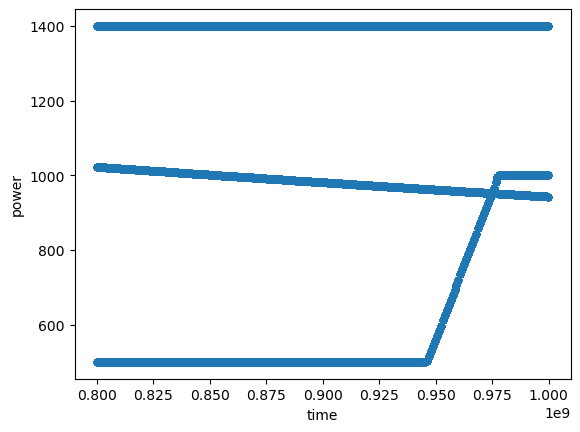

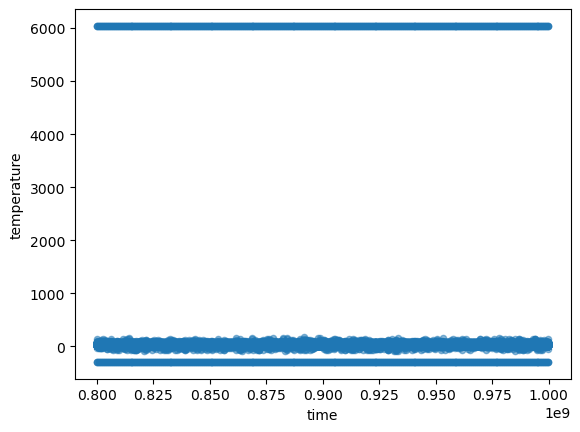

In [ ]:
b = training_data.query("time <= 10**9 and time >= 0.8*10**9")
b.plot.scatter(x="time", y="power", alpha=0.5)
b.plot.scatter(x="time", y="temperature", alpha=0.5)



<Axes: xlabel='power', ylabel='temperature'>

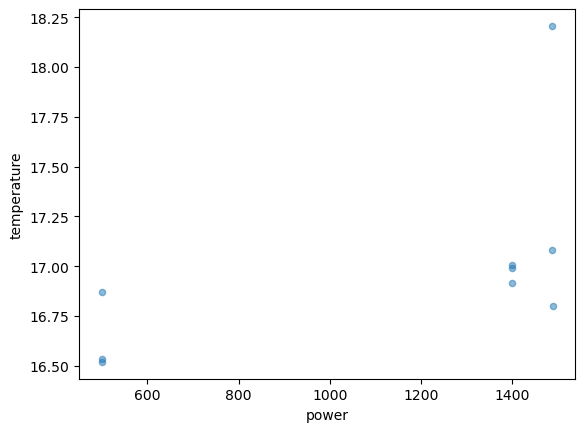

In [ ]:
#for sens in training_data["sensors"]:
 #   print(sens)
sampleP=training_data.query("time <= 1800000 and sensor=='N418'")
sampleP.head(10)

sampleP.plot.scatter(x="power", y="temperature", alpha=0.5)
#mean.plot.scatter(x="time", y="temperature", alpha=0.5)

<Axes: xlabel='time', ylabel='power'>

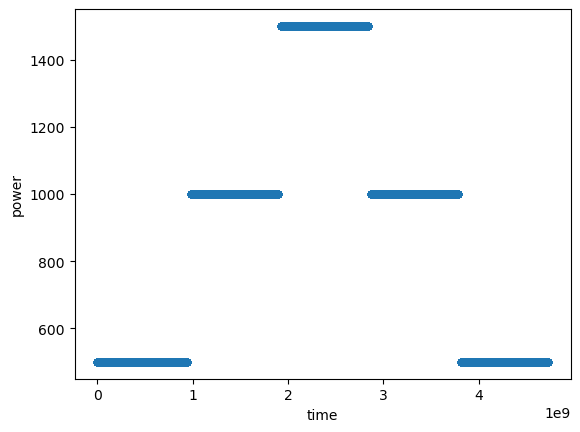

In [ ]:
a = sampleP["power"].diff(periods=864000)

a.head(20)
power1 = training_data.query("power == 500.0000 or power == 1000.0000 or power == 1500.0000")
power1.plot.scatter(x="time", y="power", alpha=0.5)


AttributeError: 'function' object has no attribute 'query'

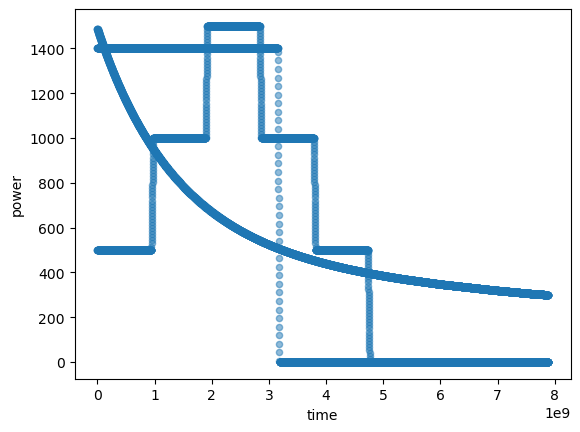

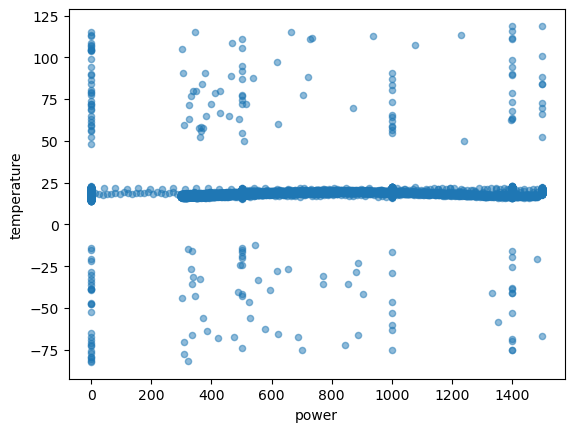

In [ ]:
"""graphes tous pour 1 senseur"""

sampleN418 = training_data.query(" sensor=='N418'")
sampleN418.plot.scatter(x="time", y="power", alpha=0.5)
sampleN418.plot.scatter(x="power", y="temperature", alpha=0.5)


In [ ]:
b = training_data.query("time <= 10**9 and time >= 0.8*10**9")
b.plot.scatter(x="time", y="power", alpha=0.5)
b.plot.scatter(x="time", y="temperature", alpha=0.5)
c=b["power"].pct_change(periods=1)


In [ ]:
sampleN418b = sampleN418.sample(1000)
sampleN418b.plot.scatter(x="time", y="power", alpha=0.5)
sampleN418b.plot.scatter(x="time", y="temperature", alpha=0.5)


In [ ]:
"""Test of the functions"""
train_data_expl = pd.DataFrame(data=np.array([[1,1,2,2,3,3,4,4,5,0],
                                     [1,3,2,4,1,3,2,4,0,5]]).T,
                                       columns=["coor_x","coor_y"], dtype='float64')
train_data_expl["sensor"] = ["N1","N2","N3","N4","N5","N6","N7","N8","N9","N10"]


test_data_expl = pd.DataFrame(data=np.array([[1.5,4.,4.5],
                                     [1.5,0.5,3.]]).T,
                                       columns=["coor_x","coor_y"], dtype = 'float64')
test_data_expl["sensor"] = ["N11","N12","N13"]

for _, sample in test_data_expl.iterrows():
  print(sample)
  print(eucli_dist(sample, train_data_expl))

coor_x    1.5
coor_y    1.5
sensor    N11
Name: 0, dtype: object
   coor_x  coor_y sensor  distance
0     1.0     1.0     N1  0.707107
1     1.0     3.0     N2  1.581139
2     2.0     2.0     N3  0.707107
3     2.0     4.0     N4  2.549510
4     3.0     1.0     N5  1.581139
5     3.0     3.0     N6  2.121320
6     4.0     2.0     N7  2.549510
7     4.0     4.0     N8  3.535534
8     5.0     0.0     N9  3.807887
9     0.0     5.0    N10  3.807887
coor_x    4.0
coor_y    0.5
sensor    N12
Name: 1, dtype: object
   coor_x  coor_y sensor  distance
0     1.0     1.0     N1  3.041381
1     1.0     3.0     N2  3.905125
2     2.0     2.0     N3  2.500000
3     2.0     4.0     N4  4.031129
4     3.0     1.0     N5  1.118034
5     3.0     3.0     N6  2.692582
6     4.0     2.0     N7  1.500000
7     4.0     4.0     N8  3.500000
8     5.0     0.0     N9  1.118034
9     0.0     5.0    N10  6.020797
coor_x    4.5
coor_y    3.0
sensor    N13
Name: 2, dtype: object
   coor_x  coor_y sensor  distance


In [ ]:


""" A Garder pour d autres tests
Sampling for TESTING ON SMALLER SETS
train_sensors = train_sensors.sample(frac = 1/5) # 20% des sensors
training_data = training_data.loc[train_sensors.index].query('time < 1e8') # 1% des times
"""

